Importing the dataset from kaggle directly

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("seungjunleeofficial/image-colorization")

print("Path to dataset files:", path)

100%|██████████| 2.94G/2.94G [02:22<00:00, 22.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/seungjunleeofficial/image-colorization/versions/1


Importing the libraries

In [ ]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from tqdm import tqdm


Creating Customised Dataset Class that contains 2 compulsory functions that are overwritten
__init__
__len__
__getitem__

In [ ]:
class ColorizationDataset(Dataset):
    def __init__(self, gray_dir, color_dir):
        self.gray_dir = gray_dir
        self.color_dir = color_dir

        #sorting the files based on there file name i.e. number in order to match the gray and colored image correctly
        self.gray_images = sorted(os.listdir(gray_dir))
        self.color_images = sorted(os.listdir(color_dir))

    def __len__(self):
        return len(self.gray_images)

    def __getitem__(self, idx):
        # creating the file path for both gray and coloured image
        gray_path = os.path.join(self.gray_dir, self.gray_images[idx])
        color_path = os.path.join(self.color_dir, self.color_images[idx])

        # reading the images from a given path created above
        gray = cv2.imread(gray_path, cv2.IMREAD_GRAYSCALE) #cv2.IMREAD_GRAYSCALE is used bcz it loads image as a single-channel grayscale.
        color = cv2.imread(color_path)

        # resizing the images to a size of 128*128
        gray = cv2.resize(gray, (128, 128))
        color = cv2.resize(color, (128, 128))

        # Normalize to [0,1]
        gray = gray.astype(np.float32) / 255.0
        color = color.astype(np.float32) / 255.0

        # Convert color to LAB
        # L = Lightness (Range 0 to 100)
        # ab = (a= green-red and b = blue-yellow) Color components (Range –128 to +127)
        lab = cv2.cvtColor(color, cv2.COLOR_BGR2LAB)
        L = lab[:, :, 0:1] / 100.0           # normalize L to [0,1]
        ab = lab[:, :, 1:3] / 128.0          # normalize ab to [-1,1]

        # converting array to pytorch tensor and transpose ((2,0,1)) changes shape from (H,W,C) to (C,H,W) bcz pyTorch expects channel first format
        L = torch.from_numpy(L.transpose((2, 0, 1))).float()
        ab = torch.from_numpy(ab.transpose((2, 0, 1))).float()

        return L, ab


Creating Dataset and Datset Loaders

In [ ]:
train_dataset = ColorizationDataset(
    gray_dir=os.path.join(path, "train/gray"),
    color_dir=os.path.join(path, "train/color")
)
test_dataset = ColorizationDataset(
    gray_dir=os.path.join(path, "val/gray"),
    color_dir=os.path.join(path, "val/color")
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

#print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")


Train samples: 118287, Test samples: 5000


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
class UNetColorization(nn.Module):
    def __init__(self):
        super(UNetColorization, self).__init__()

        def CBR(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.LeakyReLU(0.2, inplace=True)
            )
        # Encoder Block = DOWNSAMPLING OPERATION
        # Extracts features from image
        self.enc1 = nn.Sequential(CBR(1, 64), CBR(64, 64)) # 64 here is representing the size of output feature map
        self.enc2 = nn.Sequential(CBR(64, 128), CBR(128, 128))
        self.enc3 = nn.Sequential(CBR(128, 256), CBR(256, 256))
        self.enc4 = nn.Sequential(CBR(256, 512), CBR(512, 512))

        # Bottleneck Block
        # the deepest part of unet
        self.bottleneck = nn.Sequential(CBR(512, 1024), CBR(1024, 512))

        # Pooling layer is used to half the spatial resolution and double the channel size
        # this is done so that as we go deeper the spatial resolution decreases so the network will compensate by learning more filter
        # resolution is done half as we can see larger regions of image means more context
        self.pool = nn.MaxPool2d(2)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        # mode='bilinear' ensures smoother interpolation during upsampling

        # Decoder = UPSAMPLING OPERATION
        # Reconstruct the image
        self.dec3 = nn.Sequential(CBR(512 + 512, 512), CBR(512, 256)) # 512(upsampled bottleneck) + 512(encoder 4)
        self.dec2 = nn.Sequential(CBR(256 + 256, 256), CBR(256, 128))
        self.dec1 = nn.Sequential(CBR(128 + 128, 128), CBR(128, 64))
        self.final_conv = nn.Conv2d(64 + 64, 2, 1)  # 2 is taken bcz of a b channels


    def forward(self, x):
        e1 = self.enc1(x)                  # 256x256
        e2 = self.enc2(self.pool(e1))      # 128x128
        e3 = self.enc3(self.pool(e2))      # 64x64
        e4 = self.enc4(self.pool(e3))      # 32x32

        b = self.bottleneck(self.pool(e4)) # 16x16

        # SKIP CONNECTIONS
        # When we downsample, we lose fine details (like edges) to recover them, we connect encoder feature maps directly to the decoder of the same scale
        d4 = self.up(b)                    # 32x32
        d4 = self.dec3(torch.cat([d4, e4], dim=1))

        d3 = self.up(d4)                   # 64x64
        d3 = self.dec2(torch.cat([d3, e3], dim=1))

        d2 = self.up(d3)                   # 128x128
        d2 = self.dec1(torch.cat([d2, e2], dim=1))

        d1 = self.up(d2)                   # 256x256
        out = self.final_conv(torch.cat([d1, e1], dim=1))
        out = torch.tanh(out) # tanh squashes output values between [-1, 1]
        return out


Training Block

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNetColorization().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

epochs = 10
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for L, ab in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        L, ab = L.to(device), ab.to(device)
        pred_ab = model(L)
        loss = criterion(pred_ab, ab)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {total_loss/len(train_loader):.4f}")


Epoch 1/10: 100%|██████████| 3697/3697 [16:08<00:00,  3.82it/s]


Epoch [1/10] Loss: 0.0111


Epoch 2/10: 100%|██████████| 3697/3697 [16:12<00:00,  3.80it/s]


Epoch [2/10] Loss: 0.0101


Epoch 3/10: 100%|██████████| 3697/3697 [16:11<00:00,  3.80it/s]


...

Epoch [8/10] Loss: 0.0089


Epoch 9/10: 100%|██████████| 3697/3697 [16:12<00:00,  3.80it/s]


Epoch [9/10] Loss: 0.0088


Epoch 10/10: 100%|██████████| 3697/3697 [16:11<00:00,  3.80it/s]

Epoch [10/10] Loss: 0.0087


Evaluation Block

In [ ]:
model.eval()
L_batch, ab_batch = next(iter(test_loader))   # get one batch
L_batch, ab_batch = L_batch.to(device), ab_batch.to(device)

with torch.no_grad():
    pred_ab_batch = model(L_batch)

Code to convert LAB to RGB

In [ ]:
def lab_to_rgb(L, ab):
    # Convert from tensors to numpy array
    L = L.squeeze().cpu().numpy()
    ab = ab.squeeze().cpu().numpy()

    # Rescale back to proper LAB ranges
    L = L * 100  # [0, 100]
    ab = ab * 128  # [-128, 128]

    # Combine into LAB image
    lab = np.concatenate((L[np.newaxis, :, :], ab), axis=0).transpose((1, 2, 0)).astype(np.float32)

    # Convert LAB → RGB correctly
    rgb = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    # Clip to [0,1] for display
    rgb = np.clip(rgb, 0, 1)
    return rgb



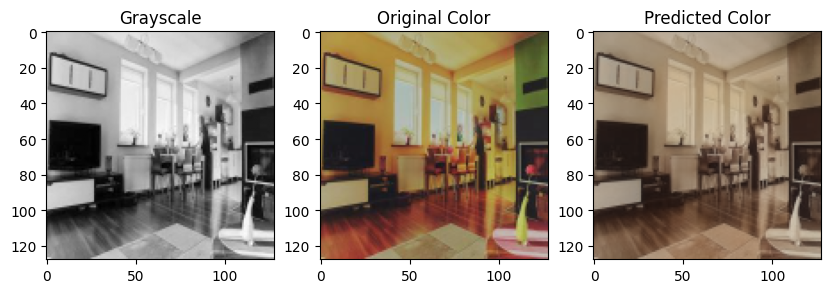

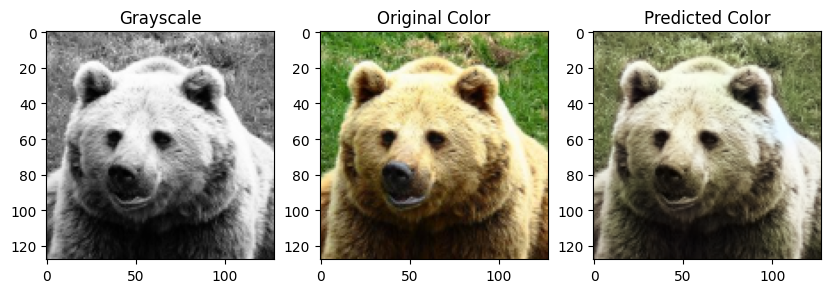

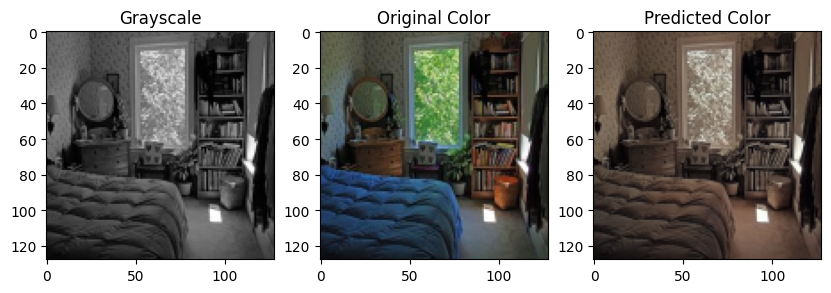

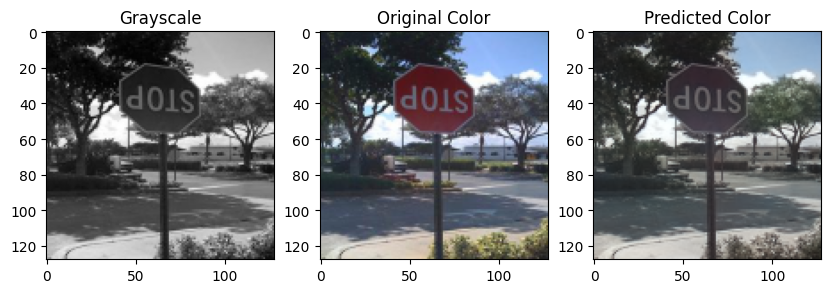

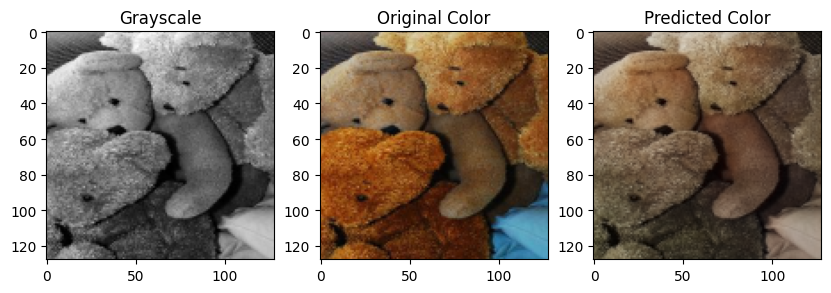

In [ ]:
model.eval()
with torch.no_grad():
    for L, ab in test_loader:
        L, ab = L.to(device), ab.to(device)
        pred_ab = model(L)
        break  # take only first batch

for i in range(5):
    gray = L[i].cpu().squeeze().numpy()
    real = lab_to_rgb(L[i].cpu(), ab[i].cpu())
    fake = lab_to_rgb(L[i].cpu(), pred_ab[i].cpu())

    plt.figure(figsize=(10,4))
    plt.subplot(1,3,1)
    plt.imshow(gray, cmap='gray')
    plt.title("Grayscale")

    plt.subplot(1,3,2)
    plt.imshow(real)
    plt.title("Original Color")

    plt.subplot(1,3,3)
    plt.imshow(fake)
    plt.title("Predicted Color")

    plt.show()


Saving the trained model

In [ ]:
torch.save(model.state_dict(), "colorization_model.pth")

For videos

In [ ]:
import cv2
import os

def extract_frames(video_path, output_folder):
    os.makedirs(output_folder, exist_ok=True)
    vidcap = cv2.VideoCapture(video_path)
    count = 0
    while True:
        success, frame = vidcap.read()
        if not success:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        cv2.imwrite(f"{output_folder}/frame_{count:04d}.png", gray)
        count += 1
    vidcap.release()
    print(f"Extracted {count} frames.")


In [ ]:
from PIL import Image
import numpy as np
import cv2
import torch
from torchvision import transforms

def lab_to_rgb(L, ab):
    # L: [1, 1, H, W]  -> de-normalize to [0,100]
    # ab: [1, 2, H, W] -> de-normalize to [-128,128]
    L = (L.cpu().numpy()[0][0] + 1.0) * 50.0   # from [-1,1] → [0,100]
    ab = (ab.cpu().numpy()[0].transpose((1, 2, 0))) * 128.0  # from [-1,1] → [-128,128]

    Lab = np.concatenate((L[..., np.newaxis], ab), axis=2).astype(np.float32)
    rgb = cv2.cvtColor(Lab, cv2.COLOR_Lab2RGB)
    rgb = np.clip(rgb, 0, 1)
    return rgb


In [ ]:
from PIL import Image

In [ ]:
model = UNetColorization()
model.load_state_dict(torch.load("colorization_model.pth", map_location=device))
model.to(device)
model.eval()

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])



In [ ]:
def colorize_frame(image_path, output_path):
    img = Image.open(image_path).convert("L")
    input_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output_ab = model(input_tensor)  # model predicts ab

    output_rgb = lab_to_rgb(input_tensor, output_ab)
    output_rgb = (output_rgb * 255).astype(np.uint8)

    # Convert RGB → BGR for OpenCV saving
    output_bgr = cv2.cvtColor(output_rgb, cv2.COLOR_RGB2BGR)
    cv2.imwrite(output_path, output_bgr)


In [ ]:
video_path = "/content/output_bw_video.mp4"
bw_frames_folder = "bw_frames_new"

extract_frames(video_path, bw_frames_folder)

Extracted 1302 frames.


In [ ]:
input_folder = "bw_frames_new"
output_folder = "colored_frames_new"
os.makedirs(output_folder, exist_ok=True)

for filename in sorted(os.listdir(input_folder)):
    colorize_frame(os.path.join(input_folder, filename),
                   os.path.join(output_folder, filename))


In [ ]:
def create_video_from_frames(frames_folder, output_video, fps=30):
    frames = sorted(os.listdir(frames_folder))
    frame_example = cv2.imread(os.path.join(frames_folder, frames[0]))
    height, width, layers = frame_example.shape

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    video = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

    for frame in frames:
        img = cv2.imread(os.path.join(frames_folder, frame))
        video.write(img)
    video.release()
    print("Video created successfully!")


In [ ]:
create_video_from_frames("colored_frames_new", "colorized_output.mp4", fps=30)

Video created successfully!
